<a id="top"></a>

<div class="list-group" id="list-tab" role="tablist">
<h1 class="list-group-item list-group-item-action active" data-toggle="list" style='background:#005097; border:0' role="tab" aria-controls="home"><center>RFM Segmentation and CLV modeling </center></h1>

### Table of Contents

* [1. Theoretical concepts](#section_1)
    * [RFM segmentation](#section_1_1)
    * [Customer Lifetime Value](#section_1_2) 
    ___
* [2. Data Preprocessing](#section_2)
    * [Feature engineering](#section_2_1)
    * [Statistical summary](#section_2_2)
    
    ___
* [3. RFM Segmentation](#section_3)
    * [Recency calculation](#section_3_1)
    * [Frequency calculation](#section_3_2)
    * [Monetary calculation](#section_3_3)
    * [Segment creation](#section_3_4)
    
    ___
* [4. CLV modeling](#section_4)
    * [Deriving RFM Metrics](#section_4_1)
    * [Retention Model fitting](#section_4_2)
    * [Value Model fitting](#section_4_3)
    * [CLV estimates](#section_4_4)
        
    ___
* [5. Conclusion](#section_5)
    
    ___

In [1]:
!pip install Lifetimes
!pip install scikit-learn-extra

     |████████████████████████████████| 584 kB 4.3 MB/s 
     |████████████████████████████████| 615 kB 4.3 MB/s 
  Installing build dependencies ... - \ | / - \ | done
  Getting requirements to build wheel ... - \ done
    Preparing wheel metadata ... - done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.1.0b2-cp37-cp37m-linux_x86_64.whl size=359218 sha256=de332ce31e5f79f51bfd1d69afc1a0bb81fb444cd6c6a2a7479740ad3fa0be6c
  Stored in directory: /root/.cache/pip/wheels/20/73/08/e2ab008d0275628ccfd985b1f2b370330104d9d4ddb995bb67
Successfully built scikit-learn-extra


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import datetime
from datetime import timedelta
from datetime import date
import squarify
from lifetimes.plotting import *
from lifetimes.utils import *
from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter
from scipy.stats import gamma, beta
from sklearn_extra.cluster import KMedoids
import warnings
warnings.filterwarnings('ignore')

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
data_folder = "/kaggle/input/arketing-campaign/"

/kaggle/input/arketing-campaign/marketing_campaign.csv
/kaggle/input/arketing-campaign/marketing_campaign.xlsx


# 1. Theoretical concepts <a class="anchor" id="section_1"></a>

### A. RFM Segmentation <a class="anchor" id="section_1_1"></a>

RFM segmentation is a scoring technique used to better quantify customer behavior. During marketing campaigns, not all customers should be contacted with the same effort. Direct marketing segmentation enables to group customers in different segments and anayze their profitability accordingly.

RFM metrics are closely related to the Customer Lifetime Value as frequency and monetary value affect directly **CLV** and recency affects **retention**
>- **Recency** : Time since last order  
>- **Frequency** : Total number of transactions
>- **Monetary** : Total transactions value

These metrics are very important to understand customer behavior :
- The more **recent** the purchase, the more **responsive** the customer is to promotions
- The more **frequently** customers buy, the more **engaged** they are

### B. Customer Lifetime Value <a class="anchor" id="section_1_2"></a>

- **CLV definition**

Customer Lifetime Value can be viewed as the economic value derived from the firm's relationship with its customers. 
CLV is defined as a measure of the present value of future cash flows attributed to the customer relationship.In other words, CLV measure the net profit a customer will bring to the firm over the future periods. Hence past customer transactions may be used as a predictive driver of the economic value of a firm's customer relationship.

The CLV formula can be written as :

$$CLV = \sum_{n=1}^{N} \frac {Value_{n}*Retention^{n}}{ (1+ DiscountRate)^{n}}$$


- **Buy Till You Die model (BTYD model)**

BTYD model is built on 4 metrics which are closely related to the ones used for RFM segmentation :
- **Frequency** : The number of repeated purchases the customer made after his first date of first purchase
- **Age** (Time) : The period the customer has been enrolled in the company, expressed in days, weeks or even months. 
   $\textit{Age = Last date in dataset - first customer purchase date }$
- **Recency** : The age of the customer when he made its last purchase  
    $\textit{Recency = Last customer purchase date - first customer purchase date }$
- **Monetary value** : The average  amount spent by a customer

While it exists several version of BTYD models, I will here use the BG/NBD model.  
BG/NBD was introduced in 2004 by Peter Fader and stands for Beta Geometric/Negative Binomial Distribution.   
The model distinguish customer behaviour in two parts:
- The buying process which models the probability a customer makes a purchase
- The dying process (or dropout) which models the probability a customer quit and never purchase again

BG/NBD model is based on 5 assumptions :
>1. While active, the number of transactions made by a customer follows a **Poisson distribution** with transaction rate $\lambda$
>2. Heterogenity in transaction rate $\lambda$ follows a **Gamma distribution** (each customer has its own probability of buying)
>3. After any transaction, a customer becomes inactive with probability $p$. The point at which a customer "drops out" (or "die") is distributed across the transactions according to a **Geometric distribution**
>4. Heterogeneity in $p$ (dropout probability) follows a **Beta distribution** 
>5. The transaction rate $\lambda$ and the dropout probability $p$ vary independently across customers

Once these probability distributions have been fitted, we obtain for each customer :
- $P(X(t)=x| \lambda ,p) $ : the probability of observing $x$ transactions in a time period of lenght $t$
- $E(X(t)| \lambda ,p) $ : the expected number of transactions in a time period of lenght $t$
- $P(\tau>t) $ : the probability of a customer becoming inactive at period $\tau$

# 2. Data Preprocessing <a class="anchor" id="section_2"></a>

We covered in the <a href="https://www.kaggle.com/raphael2711/data-prep-visual-eda-and-statistical-hypothesis">previous notebooks</a> the data discovery steps (data types, data shape, data completeness, etc..)  
We will therefore directly start with the feature engineering step and the analysis of the statistical metrics relevant for this usecase.

### A. Feature Engineering <a class="anchor" id="section_2_1"></a>

In [3]:
dataset=pd.read_csv(data_folder+'marketing_campaign.csv',header=0,sep=';') 
dataset.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,2013-09-09,16,520,...,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,2012-11-13,34,235,...,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,2013-05-08,32,76,...,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,2013-06-06,19,14,...,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,2014-03-13,68,28,...,20,1,0,0,0,0,0,3,11,0


The dataset already have all the variables needed to create the RFM metrics. We just need to prepare the data.

We wrill create two variables :

>- Variable __*Spending*__ as the sum of the amount spent on the 6 product categories.
>- Variable __*Transactions*__ as the total number of purchases made by the customer.


We will remove the unused variables for this analysis and keep only the customers who made more than 1 repeat purchase in order to calculate the Customer Lifetime Value.

In [4]:
dataset['Spending']=dataset['MntWines']+dataset['MntFruits']+dataset['MntMeatProducts']+dataset['MntFishProducts']+dataset['MntSweetProducts']+dataset['MntGoldProds']
dataset['Transactions']=dataset['NumWebPurchases']+dataset['NumCatalogPurchases']+dataset['NumStorePurchases']
dataset=dataset[['ID','Spending','Transactions','Recency','Dt_Customer']]
dataset = dataset[dataset['Transactions'] > 1] #We keep customers with repeated purchases, implying number of transactions must be at least 2
dataset = dataset[dataset['Spending'] > 0]

### B. Statistical Summary <a class="anchor" id="section_2_2"></a>

In [5]:
print("Summary of the last 2 years spending")
print("Number of transactions: ", dataset['Transactions'].sum())
print("Total sales: ",dataset['Spending'].sum())
print("Number of customers:", dataset['ID'].nunique())

Summary of the last 2 years spending
Number of transactions:  28077
Total sales:  1354764
Number of customers: 2228


# 3. RFM Segmentation <a class="anchor" id="section_3"></a>

### A. Recency calculation <a class="anchor" id="section_3_1"></a>

In [6]:
recency_df = dataset[['ID','Recency']]
recency_df

,ID,Recency
0,5524,58
1,2174,38
2,4141,26
3,6182,26
4,5324,94
...,...,...
2235,10870,46
2236,4001,56
2237,7270,91
2238,8235,8


### B. Frequency calculation <a class="anchor" id="section_3_2"></a>

In [7]:
frequency_df = dataset[['ID','Transactions']]
temp_df = recency_df.merge(frequency_df,on='ID')
frequency_df

,ID,Transactions
0,5524,22
1,2174,4
2,4141,20
3,6182,6
4,5324,14
...,...,...
2235,10870,16
2236,4001,15
2237,7270,18
2238,8235,21


### C. Monetary calculation <a class="anchor" id="section_3_3"></a>

In [8]:
monetary_df = dataset[['ID','Spending']]
monetary_df

,ID,Spending
0,5524,1617
1,2174,27
2,4141,776
3,6182,53
4,5324,422
...,...,...
2235,10870,1341
2236,4001,444
2237,7270,1241
2238,8235,843


#### DataFrame aggregation

In [9]:
tx_user  = temp_df.merge(monetary_df,on='ID')
tx_user.columns = ['ID','Recency','Frequency','Monetary']
tx_user

,ID,Recency,Frequency,Monetary
0,5524,58,22,1617
1,2174,38,4,27
2,4141,26,20,776
3,6182,26,6,53
4,5324,94,14,422
...,...,...,...,...
2223,10870,46,16,1341
2224,4001,56,15,444
2225,7270,91,18,1241
2226,8235,8,21,843


#### Elbow method

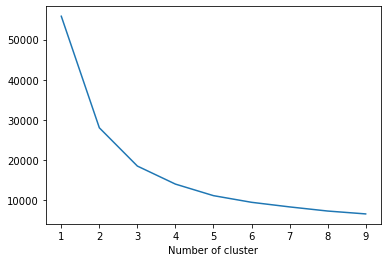

In [10]:
#Select number of clusters for each attributes
#Step 1 : Clusters for Recency
sse={}
tx_recency = tx_user[['Recency']]
for k in range(1, 10):
    kmedoids = KMedoids(n_clusters=k, random_state=0, max_iter=1000,init='k-medoids++',metric='euclidean').fit(tx_recency)
    tx_recency["clusters"] = kmedoids.labels_
    sse[k] = kmedoids.inertia_
plt.figure()
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of cluster")
plt.show()

In this analysis we will divide our customers in 5 clusters for each RFM metrics leading to 5x5x5 clusters

#### Recency clusters creation

In [11]:
kmedoids = KMedoids(n_clusters=5, random_state=0, max_iter=1000,init='k-medoids++',metric='euclidean').fit(tx_recency)
tx_user['RecencyCluster'] = kmedoids.predict(tx_recency)

#function for ordering cluster numbers
def order_cluster(cluster_field_name, target_field_name,df,ascending):
    new_cluster_field_name = 'new_' + cluster_field_name
    df_new = df.groupby(cluster_field_name)[target_field_name].mean().reset_index()
    df_new = df_new.sort_values(by=target_field_name,ascending=ascending).reset_index(drop=True)
    df_new['index'] = df_new.index
    df_final = pd.merge(df,df_new[[cluster_field_name,'index']], on=cluster_field_name)
    df_final = df_final.drop([cluster_field_name],axis=1)
    df_final = df_final.rename(columns={"index":cluster_field_name})
    return df_final

tx_user = order_cluster('RecencyCluster', 'Recency',tx_user,False)
#see details of each cluster
tx_user.groupby('RecencyCluster')['Recency'].describe()

,count,mean,std,min,25%,50%,75%,max
RecencyCluster,,,,,,,,
0,347.0,91.438040,4.549477,84.0,87.0,92.0,95.0,99.0
1,488.0,72.709016,6.357695,62.0,67.0,73.0,78.0,83.0
2,466.0,51.255365,5.675189,41.0,47.0,51.0,56.0,61.0
3,431.0,30.816705,5.447107,22.0,26.0,30.0,36.0,40.0
4,496.0,10.058468,6.428048,0.0,4.0,10.0,16.0,21.0


#### Frequency clusters creation

In [12]:
tx_frequency = tx_user[['Frequency']]

kmedoids = KMedoids(n_clusters=5, random_state=0, max_iter=1000,init='k-medoids++',metric='euclidean').fit(tx_frequency)
tx_user['FrequencyCluster'] = kmedoids.predict(tx_frequency)

#order the frequency cluster
tx_user = order_cluster('FrequencyCluster', 'Frequency',tx_user,True)

#see details of each cluster
tx_user.groupby('FrequencyCluster')['Frequency'].describe()

,count,mean,std,min,25%,50%,75%,max
FrequencyCluster,,,,,,,,
0,512.0,4.093750,0.780762,2.0,3.0,4.0,5.0,5.0
1,415.0,6.879518,1.002384,6.0,6.0,7.0,7.0,9.0
2,270.0,11.592593,1.096098,10.0,11.0,12.0,13.0,13.0
3,475.0,16.027368,1.444212,14.0,15.0,16.0,17.0,18.0
4,556.0,22.271583,2.676555,19.0,20.0,22.0,24.0,32.0


#### Monetary clusters creation

In [13]:
tx_monetary = tx_user[['Monetary']]

kmedoids = KMedoids(n_clusters=5, random_state=0, max_iter=1000,init='k-medoids++',metric='euclidean').fit(tx_monetary)
tx_user['MonetaryCluster'] = kmedoids.predict(tx_monetary)

#order the cluster numbers
tx_user = order_cluster('MonetaryCluster', 'Monetary',tx_user,True)

#show details of the dataframe
tx_user.groupby('MonetaryCluster')['Monetary'].describe()

,count,mean,std,min,25%,50%,75%,max
MonetaryCluster,,,,,,,,
0,925.0,74.211892,52.763752,8.0,37.0,57.0,96.0,227.0
1,400.0,405.912500,110.965617,231.0,310.0,405.0,493.0,614.0
2,307.0,823.648208,111.827803,615.0,729.5,823.0,921.0,1003.0
3,322.0,1202.472050,124.808991,1004.0,1097.5,1183.5,1313.0,1443.0
4,274.0,1765.317518,243.744698,1445.0,1574.0,1701.5,1919.0,2525.0


### D. Segment creation <a class="anchor" id="section_3_4"></a>

In order to keep a manageable number of segments, the segments are created using only the recency and frequency scores.  
The monetary score is often viewed as an aggregation metric for summarizing transactions.

In [14]:
segt_map = {
    r'30': 'Promising',
    r'23': 'Loyal customers',
    r'24': 'Loyal customers',
    r'33': 'Loyal customers',
    r'34': 'Loyal customers',
    r'43': 'Loyal customers',
    r'32': 'Potential loyalist',
    r'31': 'Potential loyalist',
    r'42': 'Potential loyalist',
    r'41': 'Potential loyalist',
    r'21': 'Need attention',
    r'22': 'Need attention',
    r'12': 'Need attention',
    r'11': 'Need attention',
    r'40': 'New customers',
    r'20': 'About to sleep',
    r'14': 'Cant loose them',
    r'04': 'Cant loose them',
    r'10': 'Lost',
    r'00': 'Lost',
    r'01': 'Lost',
    r'02': 'At risk',
    r'03': 'At risk',
    r'13': 'At risk',
    r'44': 'Champions',
}

tx_user['Segment'] = tx_user['RecencyCluster'].map(str) + tx_user['FrequencyCluster'].map(str)
tx_user['Segment'] = tx_user['Segment'].replace(segt_map, regex=True)
tx_user.head()

,ID,Recency,Frequency,Monetary,RecencyCluster,FrequencyCluster,MonetaryCluster,Segment
0,5524,58,22,1617,2,4,4,Loyal customers
1,5376,42,28,1730,2,4,4,Loyal customers
2,2225,54,20,1617,2,4,4,Loyal customers
3,6260,55,26,1957,2,4,4,Loyal customers
4,821,46,21,2077,2,4,4,Loyal customers


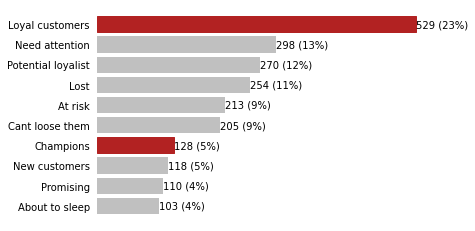

In [15]:
# count the number of customers in each segment
segments_counts = tx_user['Segment'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots()

bars = ax.barh(range(len(segments_counts)),
              segments_counts,
              color='silver')
ax.set_frame_on(False)
ax.tick_params(left=False,
               bottom=False,
               labelbottom=False)
ax.set_yticks(range(len(segments_counts)))
ax.set_yticklabels(segments_counts.index)

for i, bar in enumerate(bars):
        value = bar.get_width()
        if segments_counts.index[i] in ['Champions', 'Loyal customers']:
            bar.set_color('firebrick')
        ax.text(value,
                bar.get_y() + bar.get_height()/2,
                '{:,} ({:}%)'.format(int(value),
                                   int(value*100/segments_counts.sum())),
                va='center',
                ha='left'
               )

plt.show()

#### Metrics analysis per segment 

In [16]:
# Calculate average values for each RFM segment, and return a size of each segment 
tx_user_viz = tx_user.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count'],
}).round(1)
# Print the aggregated dataset
tx_user_viz

Recency Frequency Monetary      
                      mean      mean     mean count
Segment                                            
About to sleep        50.8       4.1     40.7   103
At risk               81.7      15.2    895.7   213
Cant loose them       81.4      22.2   1270.1   205
Champions             10.9      22.2   1172.0   128
Lost                  83.8       5.0     66.8   254
Loyal customers       35.5      18.7   1077.1   529
Need attention        62.7       8.7    291.1   298
New customers         10.3       4.1     43.9   118
Potential loyalist    19.5       8.7    246.3   270
Promising             31.4       4.1     38.2   110

#### Segment visualization

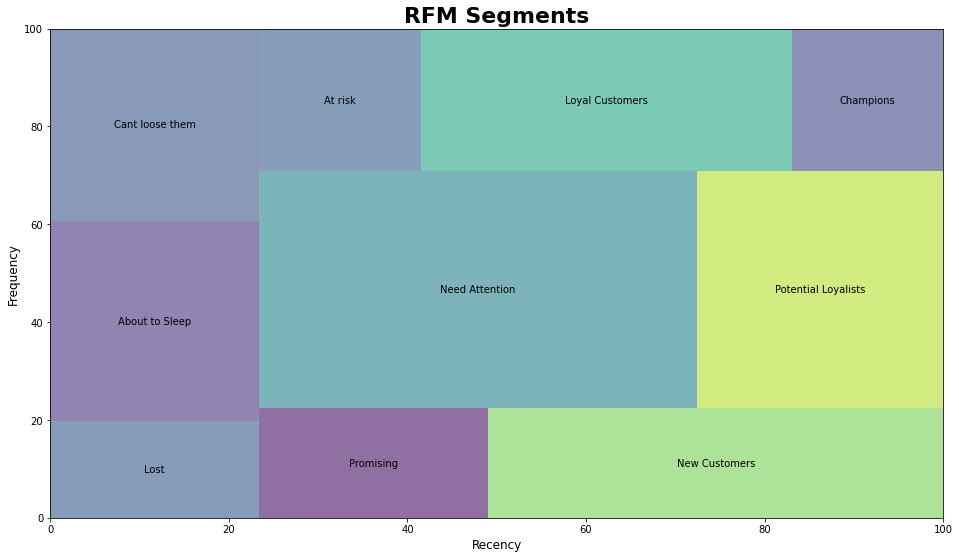

In [17]:
tx_user_viz.columns = ['Recencymean','Frequencymean', 'Monetarymean','Count']
fig = plt.gcf()
ax = fig.add_subplot()
fig.set_size_inches(16, 9)
squarify.plot(sizes=tx_user_viz['Count'], 
              label=['Lost',
                     'About to Sleep',
                     'Cant loose them',
                     'Promising',
                     'New Customers',
                     'Need Attention',
                     'Potential Loyalists',
                     'At risk',
                     'Loyal Customers',
                     'Champions',
                     ], alpha=.6 )
plt.title("RFM Segments",fontsize=22,fontweight="bold")
ax.set_xlabel('Recency',fontsize=12)
ax.set_ylabel('Frequency',fontsize=12)
plt.axis('on')
plt.show()

# 4. CLV modeling <a class="anchor" id="section_4"></a>

### A. Deriving RFM Metrics <a class="anchor" id="section_4_1"></a>

To calculate CLV, we will retrieve the "DT_Customer" which will help us calculate the Recency and Age variables in our BTYD model.  
`Note that Recency that we will use in our BTYD model is different that the one we used in our RFM segmentation `

In [18]:
tx_user  = tx_user.merge(dataset[['ID','Dt_Customer']],on='ID')
tx_user.head(10)

,ID,Recency,Frequency,Monetary,RecencyCluster,FrequencyCluster,MonetaryCluster,Segment,Dt_Customer
0,5524,58,22,1617,2,4,4,Loyal customers,2012-09-04
1,5376,42,28,1730,2,4,4,Loyal customers,2013-01-06
2,2225,54,20,1617,2,4,4,Loyal customers,2014-06-07
3,6260,55,26,1957,2,4,4,Loyal customers,2012-11-19
4,821,46,21,2077,2,4,4,Loyal customers,2012-10-19
5,8717,56,27,1835,2,4,4,Loyal customers,2012-09-12
6,8932,57,21,1531,2,4,4,Loyal customers,2012-10-29
7,6320,42,22,1508,2,4,4,Loyal customers,2013-02-06
8,3428,56,23,1598,2,4,4,Loyal customers,2013-10-06
9,1340,42,26,1795,2,4,4,Loyal customers,2014-04-24


#### Metrics calculation

In [19]:
last_date = date(2014,10, 4)
tx_user['Age']=pd.to_datetime(tx_user['Dt_Customer'], dayfirst=True,format = '%Y-%m-%d')
tx_user['Age'] = pd.to_numeric(tx_user['Age'].dt.date.apply(lambda x: (last_date - x)).dt.days, downcast='integer')

tx_user['Recency']=(tx_user['Age']-tx_user['Recency'])

tx_user['Monetary_value']=tx_user['Monetary']/tx_user['Frequency']
tx_user['Frequency']=tx_user['Frequency']-1

In [20]:
tx_user=tx_user[['ID','Frequency','Recency','Age','Monetary_value','Segment']]
tx_user

,ID,Frequency,Recency,Age,Monetary_value,Segment
0,5524,21,702,760,73.500000,Loyal customers
1,5376,27,594,636,61.785714,Loyal customers
2,2225,19,65,119,80.850000,Loyal customers
3,6260,25,629,684,75.269231,Loyal customers
4,821,20,669,715,98.904762,Loyal customers
...,...,...,...,...,...,...
2223,9014,5,35,100,10.166667,Need attention
2224,7620,5,354,425,17.666667,Need attention
2225,5959,8,639,719,22.111111,Need attention
2226,4333,5,119,195,9.000000,Need attention


### B. Retention Model fitting <a class="anchor" id="section_4_2"></a>

In [21]:
bgf = BetaGeoFitter(penalizer_coef=0.000000005)
bgf.fit(tx_user['Frequency'], tx_user['Recency'], tx_user['Age'])

<lifetimes.BetaGeoFitter: fitted with 2228 subjects, a: 4.70, alpha: 39.75, b: 441.32, r: 1.42>

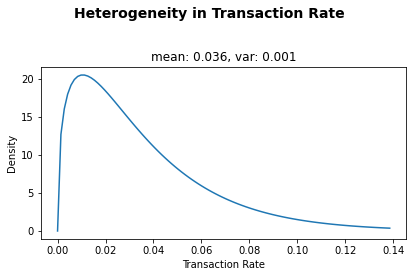

In [22]:
# plot the estimated gamma distribution of λ (customers' propensities to purchase)
plot_transaction_rate_heterogeneity(bgf);

In [23]:
bgf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
r,1.417456,0.047282,1.324782,1.510130
alpha,39.745628,1.659255,36.493489,42.997768
a,4.703731,1.370331,2.017881,7.389580
b,441.315362,123.459804,199.334146,683.296577


The summary above shows the estimated distribution parameter values from the dataset.   
The model can now use this parameters to predict the future number of transactions for each customer and their churn rate.

#### The Frequency/Recency Heatmap helps us better understanding how the model estimates the  probability of a customer still being alive and their expected number of future purchases

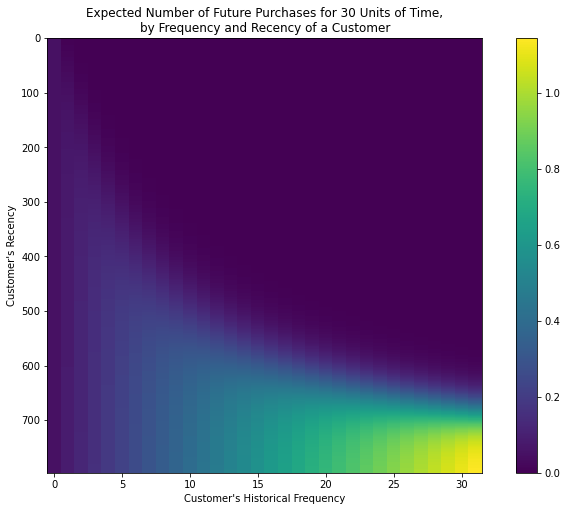

In [24]:
# visualize our frequency/recency matrix
fig = plt.figure(figsize=(12,8))
plot_frequency_recency_matrix(bgf, T = 30);

>- We can easily understand from the above heatmap that if a customer has made 30 transactions and their latest purchase as when they were 700 days old, then they are considered as the **best customers** and are more likely to buy in the following 30 days. (bottom right)  
>- We can also notice the interesting area in light blue around (5 ; 500) which represents customers who buy infrequently but we have seen them recently. We are not sure if they are dead or if they might purchase again soon. (probability around 0.5) 

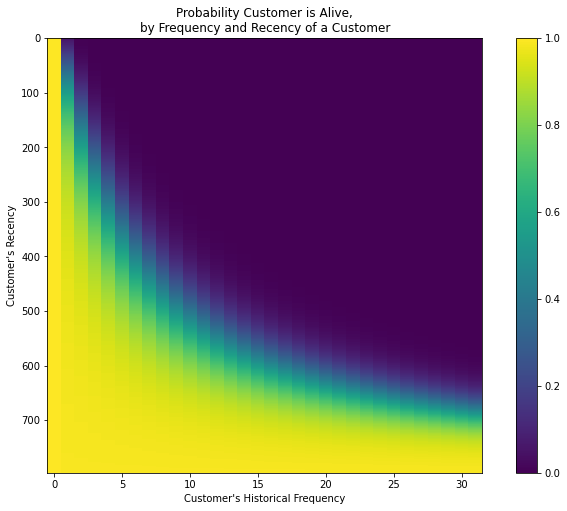

In [25]:
fig = plt.figure(figsize=(12,8))
plot_probability_alive_matrix(bgf);

The second interesing heatmap is the probability of a customer of still being alive.
>- If a customer has a high number of transactions (frequency) and the time between their first and last transaction is hight (recency), his/her probability of still being alive is high. (bottom right)  
>- If a customer has a small number of transactions but the recency is low, then his/her probability of still being alive is also high (top left)

#### Estimates the expected number of repeat purchases for each customer

In this step, we will predict the number of repeat purchase each customer will make in the next 30 days

In [26]:
t = 30 # to calculate the number of expected repeat purchases over the next 30 days
tx_user['Predicted_purchases'] = bgf.conditional_expected_number_of_purchases_up_to_time(t, tx_user['Frequency'], tx_user['Recency'], tx_user['Age'])
tx_user.sort_values(by='Predicted_purchases').tail(5)

,ID,Frequency,Recency,Age,Monetary_value,Segment,Predicted_purchases
680,9369,30,180,199,41.096774,Champions,3.408258
699,1446,26,170,182,45.407407,Champions,3.478101
420,6815,20,130,134,38.523810,Champions,3.566978
410,4828,19,96,108,39.600000,Champions,3.834860
906,4619,26,120,129,10.259259,Champions,4.548006


#### Estimates the probability of a customer still being alive

In [27]:
tx_user['p_alive'] = bgf.conditional_probability_alive(tx_user['Frequency'], tx_user['Recency'], tx_user['Age'])
tx_user.sort_values(by='Predicted_purchases').tail(5)

,ID,Frequency,Recency,Age,Monetary_value,Segment,Predicted_purchases,p_alive
680,9369,30,180,199,41.096774,Champions,3.408258,0.880761
699,1446,26,170,182,45.407407,Champions,3.478101,0.955686
420,6815,20,130,134,38.523810,Champions,3.566978,0.983451
410,4828,19,96,108,39.600000,Champions,3.834860,0.945413
906,4619,26,120,129,10.259259,Champions,4.548006,0.956635


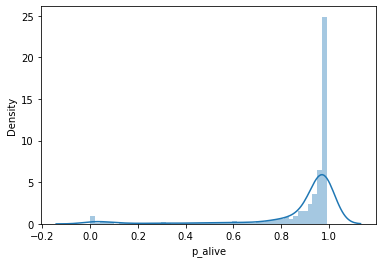

In [28]:
sns.distplot(tx_user['p_alive']);

### C. Value Model fitting <a class="anchor" id="section_4_3"></a>

In [29]:
# We fit the Gamma-Gamma model to our data
ggf = GammaGammaFitter(penalizer_coef=0.00005)
ggf.fit(frequency = tx_user['Frequency'], monetary_value = tx_user['Monetary_value'])

<lifetimes.GammaGammaFitter: fitted with 2228 subjects, p: 2.06, q: 1.88, v: 20.19>

#### Estimates the average transaction value for each customer

In [30]:
tx_user['predicted_Sales'] = ggf.conditional_expected_average_profit(tx_user['Frequency'], tx_user['Monetary_value'])
tx_user.head()

,ID,Frequency,Recency,Age,Monetary_value,Segment,Predicted_purchases,p_alive,predicted_Sales
0,5524,21,702,760,73.500000,Loyal customers,0.793468,0.947746,72.986529
1,5376,27,594,636,61.785714,Loyal customers,1.179900,0.941317,61.565831
2,2225,19,65,119,80.850000,Loyal customers,0.074461,0.019694,80.123100
3,6260,25,629,684,75.269231,Loyal customers,1.006737,0.924591,74.807016
4,821,20,669,715,98.904762,Loyal customers,0.815457,0.962194,97.838358


We can quickly check if the predicted sales and the actual sales are not 

In [31]:
print(f"Expected Average sales: {tx_user['predicted_Sales'].mean()}")
print(f"Actual Average sales: {tx_user['Monetary_value'].mean()}")

Expected Average sales: 38.74736855673988
Actual Average sales: 37.32935718606425


The results we got are fine. We can now calculate the Customer Lifetime Values

### D. CLV estimates <a class="anchor" id="section_4_4"></a>

In this final step, we calculate the Long Term Value for each customer over the next 12 months. As explained in the theorical part, we will assume a monthly discount rate of 1%

In [32]:
tx_user['LTV'] = ggf.customer_lifetime_value(bgf,tx_user['Frequency'], tx_user['Recency'], tx_user['Age'], tx_user['Monetary_value'],
    time = 12,freq='D',discount_rate = 0.01)
tx_user.head()

,ID,Frequency,Recency,Age,Monetary_value,Segment,Predicted_purchases,p_alive,predicted_Sales,LTV
0,5524,21,702,760,73.500000,Loyal customers,0.793468,0.947746,72.986529,622.074473
1,5376,27,594,636,61.785714,Loyal customers,1.179900,0.941317,61.565831,763.865260
2,2225,19,65,119,80.850000,Loyal customers,0.074461,0.019694,80.123100,54.871546
3,6260,25,629,684,75.269231,Loyal customers,1.006737,0.924591,74.807016,798.594798
4,821,20,669,715,98.904762,Loyal customers,0.815457,0.962194,97.838358,856.353519


We can plot our top 10 customers based on LTV.  
We can see that these 10 customers all belong to the Champions/Loyal customers/Potential loyalist segments

In [33]:
pd.options.display.float_format = "{:.2f}".format
best_projected_cust_LTV = tx_user.sort_values('LTV').tail(10)
best_projected_cust_LTV

,ID,Frequency,Recency,Age,Monetary_value,Segment,Predicted_purchases,p_alive,predicted_Sales,LTV
216,8029,13,131,158,115.79,Loyal customers,1.99,0.92,113.63,2252.21
840,1826,13,110,110,85.00,Loyal customers,2.81,0.99,83.82,2265.18
69,2186,20,178,208,107.48,Loyal customers,2.20,0.86,106.23,2290.54
142,9264,20,159,160,78.00,Champions,3.13,0.99,77.37,2297.33
134,3005,21,149,156,75.00,Champions,3.30,0.98,74.46,2308.53
248,1619,15,157,159,99.25,Loyal customers,2.42,0.99,97.83,2321.73
141,10133,24,218,234,93.96,Champions,2.62,0.96,93.15,2374.95
766,7959,9,109,128,137.00,Potential loyalist,1.78,0.96,132.97,2389.14
222,5350,16,204,233,148.53,Loyal customers,1.77,0.93,145.92,2610.36
219,5735,16,204,233,148.53,Loyal customers,1.77,0.93,145.92,2610.36


# 5. Conclusion <a class="anchor" id="section_5"></a>

We can now calculate the average Long Term Value of each RFM segment we define earlier for the next 12 months

In [34]:
pd.options.display.float_format = "{:.0f}".format
# Calculate average values for each RFM segment
tx_user_clv = tx_user.groupby('Segment').agg({'LTV': 'mean',}).sort_values('LTV',ascending=False)
tx_user_clv

,LTV
Segment,
Champions,801
Loyal customers,658
Cant loose them,403
At risk,355
Need attention,200
Potential loyalist,197
Lost,65
New customers,62
Promising,61


We can see that segments with the highest LTV values are the **Champions**, followed just after by the **Loyal customers**.  
We can use our new RFM segmentation along the LTV to develop a classification model and determine wich customers are most likely to be receptive to our next promotionnal marketing campaign